# Approach V2.

In [ ]:
# Libraries

import numpy as np
import pandas as pd
import requests
import time
from numpy._core.defchararray import zfill
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix
from os import scandir
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import files
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score

In [ ]:
# Load datasets
uploaded = files.upload()

Saving MantenimientoDrenaje.csv to MantenimientoDrenaje.csv
Saving MantenimientoAlcantarilla.csv to MantenimientoAlcantarilla.csv
Saving FugaDeAgua.csv to FugaDeAgua.csv


In [ ]:
# Put the exact name of one of your downloaded C5 files here
df_mantenimiento_drenaje = pd.read_csv('MantenimientoDrenaje.csv')
df_mantenimiento_alcantarilla = pd.read_csv('MantenimientoAlcantarilla.csv')
df_fuga_de_agua = pd.read_csv('FugaDeAgua.csv')

Data samples for each dataset

In [ ]:
df_mantenimiento_drenaje.head(3)

,id_folio,fecha_solicitud,hora_solicitud,tipo_de_entrada,tema_solicitud,sexo,edad,colonia_solicitud,alcaldia_solicitud,codigo_postal_solicitud,estatus,fecha_concluido,latitud,longitud
0,3212205,2025-04-10,12:04:58,Usuarios SUAC Dependencia,MANTENIMIENTO DRENAJE,Masculino,NaN,NaN,NaN,04380,Cerrado,2025-04-22,NaN,NaN
1,3212681,2025-04-10,12:09:02,Interoperabilidad SACMEX,MANTENIMIENTO DRENAJE,No especificado,NaN,STA CRUZ ATOYAC,14.0,3310,Atendido,2025-07-29,19.367732,-99.161905
2,3212753,2025-04-10,13:18:39,Operador Telefónico LOCATEL,MANTENIMIENTO DRENAJE,No especificado,NaN,NaN,NaN,01400,Atendido,2025-07-29,NaN,NaN


In [ ]:
df_mantenimiento_alcantarilla.head(3)

,id_folio,fecha_solicitud,hora_solicitud,tipo_de_entrada,tema_solicitud,sexo,edad,colonia_solicitud,alcaldia_solicitud,codigo_postal_solicitud,estatus,fecha_concluido,latitud,longitud
0,3212212,2025-04-10,11:06:02,Interoperabilidad SACMEX,MANTENIMIENTO DE COLADERA / ALCANTARILLA,No especificado,NaN,CUAUHTEMOC,15.0,6500,Atendido,2025-07-29,19.431219,-99.165014
1,3212320,2025-04-10,12:20:38,Usuarios SUAC Dependencia,MANTENIMIENTO DE COLADERA / ALCANTARILLA,Masculino,53.0,NaN,NaN,10910,Cerrado,2025-05-23,NaN,NaN
2,3212348,2025-04-10,12:24:17,Operador Telefónico LOCATEL,MANTENIMIENTO DE COLADERA / ALCANTARILLA,No especificado,NaN,NaN,NaN,04970,Atendido,2025-08-27,NaN,NaN


In [ ]:
df_fuga_de_agua.head(3)

,id_folio,fecha_solicitud,hora_solicitud,tipo_de_entrada,tema_solicitud,sexo,edad,colonia_solicitud,alcaldia_solicitud,codigo_postal_solicitud,estatus,fecha_concluido,latitud,longitud
0,3212221,2025-04-10,11:07:02,Interoperabilidad SACMEX,FUGA DE AGUA,No especificado,NaN,CTM ATZACOALCO,5.0,7090,Cerrado,2025-04-11,19.508236,-99.099069
1,3212235,2025-04-10,11:09:02,Interoperabilidad SACMEX,FUGA DE AGUA,No especificado,NaN,VALLE DEL TEPEYAC,5.0,7740,Cerrado,2025-04-21,19.489393,-99.142925
2,3212239,2025-04-10,12:09:29.085,Portal Ciudadano SUAC,FUGA DE AGUA,Masculino,NaN,LA CASILDA,5.0,07150,Cerrado,2025-06-09,19.556283,-99.123968


Information about each dataset

In [ ]:
df_mantenimiento_alcantarilla.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87539 entries, 0 to 87538
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_folio                 87539 non-null  int64  
 1   fecha_solicitud          87539 non-null  object 
 2   hora_solicitud           87539 non-null  object 
 3   tipo_de_entrada          87539 non-null  object 
 4   tema_solicitud           87539 non-null  object 
 5   sexo                     69904 non-null  object 
 6   edad                     19487 non-null  float64
 7   colonia_solicitud        45426 non-null  object 
 8   alcaldia_solicitud       45426 non-null  float64
 9   codigo_postal_solicitud  85128 non-null  object 
 10  estatus                  87539 non-null  object 
 11  fecha_concluido          81990 non-null  object 
 12  latitud                  44065 non-null  float64
 13  longitud                 43857 non-null  float64
dtypes: float64(4), int64(1

In [ ]:
df_mantenimiento_drenaje.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46445 entries, 0 to 46444
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_folio                 46445 non-null  int64  
 1   fecha_solicitud          46445 non-null  object 
 2   hora_solicitud           46445 non-null  object 
 3   tipo_de_entrada          46445 non-null  object 
 4   tema_solicitud           46445 non-null  object 
 5   sexo                     39417 non-null  object 
 6   edad                     14786 non-null  float64
 7   colonia_solicitud        25267 non-null  object 
 8   alcaldia_solicitud       25267 non-null  float64
 9   codigo_postal_solicitud  45766 non-null  object 
 10  estatus                  46445 non-null  object 
 11  fecha_concluido          44287 non-null  object 
 12  latitud                  24262 non-null  float64
 13  longitud                 24226 non-null  float64
dtypes: float64(4), int64(1

In [ ]:
df_fuga_de_agua.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225130 entries, 0 to 225129
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id_folio                 225130 non-null  int64  
 1   fecha_solicitud          225130 non-null  object 
 2   hora_solicitud           225130 non-null  object 
 3   tipo_de_entrada          225130 non-null  object 
 4   tema_solicitud           225130 non-null  object 
 5   sexo                     198935 non-null  object 
 6   edad                     50057 non-null   float64
 7   colonia_solicitud        137237 non-null  object 
 8   alcaldia_solicitud       137237 non-null  float64
 9   codigo_postal_solicitud  220574 non-null  object 
 10  estatus                  225130 non-null  object 
 11  fecha_concluido          213079 non-null  object 
 12  latitud                  133895 non-null  float64
 13  longitud                 133580 non-null  float64
dtypes: f

Through a helper function, we'll only preserve those fields that helps assign a location (alcaldia) for the incident, either by using the latitude and longitude, the zip code, neighborhood or Municipality.

First we'll only work with the geographical columns

In [ ]:
required_columns = [
        'fecha_solicitud',
        'hora_solicitud',
        'tema_solicitud',
        'colonia_solicitud',
        'alcaldia_solicitud',
        'codigo_postal_solicitud',
        'latitud',
        'longitud']


def only_geographical_columns(dataset):
  actual_columns = [col for col in required_columns if col in dataset.columns]
  adjusted_df = dataset[actual_columns].copy()
  return adjusted_df

In [ ]:
# Applied to each dataset
df_mantenimiento_drenaje_adjusted = only_geographical_columns(df_mantenimiento_drenaje)
df_mantenimiento_alcantarilla_adjusted = only_geographical_columns(df_mantenimiento_alcantarilla)
df_fuga_de_agua_adjusted = only_geographical_columns(df_fuga_de_agua)

In [ ]:
df_mantenimiento_drenaje_adjusted.head(3)


,fecha_solicitud,hora_solicitud,tema_solicitud,colonia_solicitud,alcaldia_solicitud,codigo_postal_solicitud,latitud,longitud
0,2025-04-10,12:04:58,MANTENIMIENTO DRENAJE,NaN,NaN,04380,NaN,NaN
1,2025-04-10,12:09:02,MANTENIMIENTO DRENAJE,STA CRUZ ATOYAC,14.0,3310,19.367732,-99.161905
2,2025-04-10,13:18:39,MANTENIMIENTO DRENAJE,NaN,NaN,01400,NaN,NaN


In [ ]:
df_mantenimiento_alcantarilla_adjusted.head(3)

,fecha_solicitud,hora_solicitud,tema_solicitud,colonia_solicitud,alcaldia_solicitud,codigo_postal_solicitud,latitud,longitud
0,2025-04-10,11:06:02,MANTENIMIENTO DE COLADERA / ALCANTARILLA,CUAUHTEMOC,15.0,6500,19.431219,-99.165014
1,2025-04-10,12:20:38,MANTENIMIENTO DE COLADERA / ALCANTARILLA,NaN,NaN,10910,NaN,NaN
2,2025-04-10,12:24:17,MANTENIMIENTO DE COLADERA / ALCANTARILLA,NaN,NaN,04970,NaN,NaN


In [ ]:
df_fuga_de_agua_adjusted.head(3)

,fecha_solicitud,hora_solicitud,tema_solicitud,colonia_solicitud,alcaldia_solicitud,codigo_postal_solicitud,latitud,longitud
0,2025-04-10,11:07:02,FUGA DE AGUA,CTM ATZACOALCO,5.0,7090,19.508236,-99.099069
1,2025-04-10,11:09:02,FUGA DE AGUA,VALLE DEL TEPEYAC,5.0,7740,19.489393,-99.142925
2,2025-04-10,12:09:29.085,FUGA DE AGUA,LA CASILDA,5.0,07150,19.556283,-99.123968


And then we'll drop all the entries that have 0 in all those values, since if at least one is present, we can conclude the municipality

In [ ]:
def clean_geographicall_nulls(dataset):
  df = dataset.copy()

  # Check the nulls
  text_columns = ['colonia_solicitud', 'alcaldia_solicitud', 'codigo_postal_solicitud']
  for col in text_columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace(['','nan','NAN','NA','NaN','Nan','None','none'], np.nan)

  # Check for coordinates
  df['latitud'] = pd.to_numeric(df['latitud'], errors='coerce')
  df['longitud'] = pd.to_numeric(df['longitud'], errors='coerce')

  items_before = len(df)

  # Check if we can identify the municipality using "alcaldia", "colonia" or zip code
  checkIfNull = (
        df['colonia_solicitud'].isna() &
        df['alcaldia_solicitud'].isna() &
        df['codigo_postal_solicitud'].isna() &
        (df['latitud'].isna() | df['longitud'].isna())
    )
  # ~: to keep only those values that we care fore
  clean_dataset = df[~checkIfNull].copy()

  items_after = len(clean_dataset)
  deleted_items = items_before - items_after

  print(f"--- Geo Data Dropped ---")
  print(f"Original records: {items_before}")
  print(f"Deleted records: {deleted_items}")
  print(f"Remaining records: {items_after}")

  return clean_dataset

In [ ]:
df_mantenimiento_drenaje_cleaned = clean_geographicall_nulls(df_mantenimiento_drenaje_adjusted)

--- Geo Data Dropped ---
Original records: 46445
Deleted records: 684
Remaining records: 45761


In [ ]:
df_mantenimiento_alcantarilla_cleaned = clean_geographicall_nulls(df_mantenimiento_alcantarilla_adjusted)

--- Geo Data Dropped ---
Original records: 87539
Deleted records: 2364
Remaining records: 85175


In [ ]:
df_fuga_de_agua_cleaned = clean_geographicall_nulls(df_fuga_de_agua_adjusted)

--- Geo Data Dropped ---
Original records: 225130
Deleted records: 4480
Remaining records: 220650


Next we will fill all the municipalities with the geographical data we have. For this part, if we have either the zip code or the latitude & longitude pairs, we can successfully indentify the municipality.

In [ ]:
df_copy = df_mantenimiento_drenaje_cleaned

In [ ]:
def fill_municipalities(dataset):

  #Create the new column, empty for the moment
  dataset['alcaldia'] = pd.Series(dtype='object')

  # Dictionary to use in the municipalities
  map_zipcode_municipality = {
        '01': 'ALVARO OBREGON', '02': 'AZCAPOTZALCO', '03': 'BENITO JUAREZ',
        '04': 'COYOACAN', '05': 'CUAJIMALPA DE MORELOS', '06': 'CUAUHTEMOC',
        '07': 'GUSTAVO A. MADERO', '08': 'IZTACALCO', '09': 'IZTAPALAPA',
        '10': 'MAGDALENA CONTRERAS', '11': 'MIGUEL HIDALGO', '12': 'MILPA ALTA',
        '13': 'TLAHUAC', '14': 'TLALPAN', '15': 'VENUSTIANO CARRANZA',
        '16': 'XOCHIMILCO'
    }

  # Get the zipcode first two digits to assign a municipality
  zipcode_prefix = (dataset['codigo_postal_solicitud']
                    .astype(str)
                    .str.extract(r'(\d+)', expand=False)
                    .fillna('')
                    .str.zfill(5)
                    .str[:2]
                  )

  # Map the zipcode using the dictionary
  mapped_municipalities = zipcode_prefix.map(map_zipcode_municipality)

  # Assign them to the new alcaldia column
  dataset.loc[mapped_municipalities.notna(), 'alcaldia'] = mapped_municipalities

  # Statistics
  total = len(dataset)
  municipality_assigned = dataset['alcaldia'].notna().sum()
  municipality_ommited = dataset['alcaldia'].isna().sum()
  print(f"Evaluated records: {total}")
  print(f"Assgined municipality to: {municipality_assigned}")
  print(f"Empty records: {municipality_ommited}") # to be checked with lat/long

  return dataset

In [ ]:
df_mantenimiento_alcantarilla_filled = fill_municipalities(df_mantenimiento_alcantarilla_cleaned)

Evaluated records: 85175
Assgined municipality to: 82917
Empty records: 2258


In [ ]:
df_mantenimiento_drenaje_filled = fill_municipalities(df_mantenimiento_drenaje_cleaned)

Evaluated records: 45761
Assgined municipality to: 44708
Empty records: 1053


In [ ]:
df_fuga_de_agua_filled = fill_municipalities(df_fuga_de_agua_cleaned)

Evaluated records: 220650
Assgined municipality to: 216340
Empty records: 4310


As the final pipeline regarding the municipality, we'll delete all the records that didn't get the municipality

In [ ]:
def clean_empty_municipalities(dataset):
  length = len(dataset)

  # drop all records that does not have a municipality assigned
  df_final = dataset.dropna(subset=['alcaldia']).copy()

  final = len(df_final)
  deleted = length - final

  print(f"--- Municipality Dropped ---")
  print(f"Original records: {length}")
  print(f"Deleted records: {deleted}")

  return df_final

In [ ]:
df_final_mantenimiento_drenaje = clean_empty_municipalities(df_mantenimiento_drenaje_filled)

--- Municipality Dropped ---
Original records: 45761
Deleted records: 1053


In [ ]:
df_final_mantenimiento_alcantarilla = clean_empty_municipalities(df_mantenimiento_alcantarilla_filled)

--- Municipality Dropped ---
Original records: 85175
Deleted records: 2258


In [ ]:
df_final_fuga_de_agua = clean_empty_municipalities(df_fuga_de_agua_filled)

--- Municipality Dropped ---
Original records: 220650
Deleted records: 4310


Next will be dropping the variables that will not give usefull information

In [ ]:
columns_to_preserve = ['fecha_solicitud', 'hora_solicitud', 'tema_solicitud', 'alcaldia']

# Note: preserve latitud and longitud if can track the location
columns_to_drop = ['colonia_solicitud', 'alcaldia_solicitud', 'codigo_postal_solicitud', 'latitud', 'longitud']

In [ ]:
df_final_mantenimiento_drenaje.drop(columns_to_drop, axis=1, inplace=True)
df_final_mantenimiento_drenaje.head(3)

,fecha_solicitud,hora_solicitud,tema_solicitud,alcaldia
0,2025-04-10,12:04:58,MANTENIMIENTO DRENAJE,COYOACAN
1,2025-04-10,12:09:02,MANTENIMIENTO DRENAJE,BENITO JUAREZ
2,2025-04-10,13:18:39,MANTENIMIENTO DRENAJE,ALVARO OBREGON


In [ ]:
df_final_mantenimiento_alcantarilla.drop(columns_to_drop, axis=1, inplace=True)
df_final_mantenimiento_alcantarilla.head(3)

,fecha_solicitud,hora_solicitud,tema_solicitud,alcaldia
0,2025-04-10,11:06:02,MANTENIMIENTO DE COLADERA / ALCANTARILLA,CUAUHTEMOC
1,2025-04-10,12:20:38,MANTENIMIENTO DE COLADERA / ALCANTARILLA,MAGDALENA CONTRERAS
2,2025-04-10,12:24:17,MANTENIMIENTO DE COLADERA / ALCANTARILLA,COYOACAN


In [ ]:
df_final_fuga_de_agua.drop(columns_to_drop, axis=1, inplace=True)
df_final_fuga_de_agua.head(3)

,fecha_solicitud,hora_solicitud,tema_solicitud,alcaldia
0,2025-04-10,11:07:02,FUGA DE AGUA,GUSTAVO A. MADERO
1,2025-04-10,11:09:02,FUGA DE AGUA,GUSTAVO A. MADERO
2,2025-04-10,12:09:29.085,FUGA DE AGUA,GUSTAVO A. MADERO


Merging the 3 datasets into a unique dataset containing all the incidents

In [ ]:
df_incidents = pd.concat([
    df_final_mantenimiento_drenaje,
    df_final_mantenimiento_alcantarilla,
    df_final_fuga_de_agua
], ignore_index=True)

df_incidents

,fecha_solicitud,hora_solicitud,tema_solicitud,alcaldia
0,2025-04-10,12:04:58,MANTENIMIENTO DRENAJE,COYOACAN
1,2025-04-10,12:09:02,MANTENIMIENTO DRENAJE,BENITO JUAREZ
2,2025-04-10,13:18:39,MANTENIMIENTO DRENAJE,ALVARO OBREGON
3,2025-04-10,12:29:07,MANTENIMIENTO DRENAJE,ALVARO OBREGON
4,2025-04-10,13:41:22.882,MANTENIMIENTO DRENAJE,GUSTAVO A. MADERO
...,...,...,...,...
343960,2025-03-02,07:30:01,FUGA DE AGUA,CUAUHTEMOC
343961,2025-03-02,07:32:09,FUGA DE AGUA,ALVARO OBREGON
343962,2025-03-02,07:38:20,FUGA DE AGUA,ALVARO OBREGON
343963,2025-03-02,07:44:02,FUGA DE AGUA,CUAUHTEMOC


We'll round down the minutes and hours to mantain only records for each hour

In [ ]:
# Round down time
def round_down_time(dataset):
    df = dataset.copy()

    time_serie = pd.to_datetime(df['fecha_solicitud'] + ' ' + df['hora_solicitud'].astype(str), errors='coerce')
    df['time'] = time_serie

    # truncate time
    df['time'] = df['time'].dt.floor('h')

    columns_to_drop = ['fecha_solicitud', 'hora_solicitud']
    df.drop(columns_to_drop, axis=1, inplace=True)

    return df

In [ ]:
df_incidents_rounded = round_down_time(df_incidents)
df_incidents_rounded.head(3)

,tema_solicitud,alcaldia,time
0,MANTENIMIENTO DRENAJE,COYOACAN,2025-04-10 12:00:00
1,MANTENIMIENTO DRENAJE,BENITO JUAREZ,2025-04-10 12:00:00
2,MANTENIMIENTO DRENAJE,ALVARO OBREGON,2025-04-10 13:00:00


We'll also add a new column to be a flag, all the rows inside the incidents dataframe will have a one, meaning an incident was reported. When merging the full dataset, if no incident was registered, it will have a 0 value.

In [ ]:
def add_incident_flag(dataset):
  df = dataset.copy()
  initial_rows = len(dataset)

  # group by incidents, if same happens, increase severity
  df_compressed = df.groupby(['alcaldia', 'time', 'tema_solicitud']).size().reset_index(name='severidad')

  # Compress exact hour incidents, if same type happens, then increase the severity
  df_compressed['incident'] = 1

  final_rows = len(df_compressed)
  duplicates_crushed = initial_rows - final_rows

  print(f"Redundant duplicates compressed: {duplicates_crushed:,}")
  print(f"Clean, unique incident hours: {final_rows:,}")

  return df_compressed

In [ ]:
df_final_incidents = add_incident_flag(df_incidents_rounded)
df_final_incidents.head(3)

Redundant duplicates compressed: 172,918
Clean, unique incident hours: 171,047


,alcaldia,time,tema_solicitud,severidad,incident
0,ALVARO OBREGON,2019-06-02 13:00:00,FUGA DE AGUA,1,1
1,ALVARO OBREGON,2019-06-03 09:00:00,FUGA DE AGUA,2,1
2,ALVARO OBREGON,2019-06-03 11:00:00,FUGA DE AGUA,2,1


Next, using Open-Meteo API we'll get all the telemetry data for weather and other climatological conditions.

In [ ]:
# Municipalities coordinates
alcaldias = {
    "ALVARO OBREGON": [19.35, -99.22], "AZCAPOTZALCO": [19.48, -99.18],
    "BENITO JUAREZ": [19.38, -99.16], "COYOACAN": [19.33, -99.16],
    "CUAJIMALPA DE MORELOS": [19.33, -99.28], "CUAUHTEMOC": [19.43, -99.14],
    "GUSTAVO A. MADERO": [19.49, -99.11], "IZTACALCO": [19.39, -99.09],
    "IZTAPALAPA": [19.34, -99.04], "MAGDALENA CONTRERAS": [19.30, -99.24],
    "MIGUEL HIDALGO": [19.43, -99.19], "MILPA ALTA": [19.19, -99.02],
    "TLAHUAC": [19.28, -99.00], "TLALPAN": [19.22, -99.17],
    "VENUSTIANO CARRANZA": [19.43, -99.09], "XOCHIMILCO": [19.25, -99.10]
}

START_DATE = "2019-01-01"
END_DATE = "2026-01-31"
BASE_URL = "https://archive-api.open-meteo.com/v1/archive"
VARIABLES = [
    "temperature_2m",
    "precipitation",
    "relative_humidity_2m",
    "soil_moisture_0_to_7cm",
    "soil_moisture_7_to_28cm",
    "soil_moisture_28_to_100cm",
    "et0_fao_evapotranspiration",
    "wind_speed_10m",
    "wind_gusts_10m"
]
VARIABLES_STRING = ",".join(VARIABLES)

dfs_weather = []

# building the dataset
for name, coords in alcaldias.items():
    print(f"Downloading: {name} ...", end = " ")
    params = {
        "latitude": coords[0],
        "longitude": coords[1],
        "start_date": START_DATE,
        "end_date": END_DATE,
        "hourly": VARIABLES_STRING,
        "timezone": "America/Mexico_City"
    }
    try:
      response = requests.get(BASE_URL, params=params)
      data = response.json()

      if "hourly" in data:
        # dump json into dataframe
        df_temp = pd.DataFrame(data["hourly"])
        df_temp["alcaldia"] = name

        dfs_weather.append(df_temp)
        print(f"{len(df_temp)} hours recorded")

      else:
        print(f"ERROR: {data.get('reason', 'Unknown error')}")

    except Exception as e:
      print(f"Failed to fetch data for {name}: {e}")

    time.sleep(65)

Downloading: ALVARO OBREGON ... 62112 hours recorded
Downloading: AZCAPOTZALCO ... 62112 hours recorded
Downloading: BENITO JUAREZ ... 62112 hours recorded
Downloading: COYOACAN ... 62112 hours recorded
Downloading: CUAJIMALPA DE MORELOS ... 62112 hours recorded
Downloading: CUAUHTEMOC ... 62112 hours recorded
Downloading: GUSTAVO A. MADERO ... 62112 hours recorded
Downloading: IZTACALCO ... 62112 hours recorded
Downloading: IZTAPALAPA ... 62112 hours recorded
Downloading: MAGDALENA CONTRERAS ... 62112 hours recorded
Downloading: MIGUEL HIDALGO ... 62112 hours recorded
Downloading: MILPA ALTA ... 62112 hours recorded
Downloading: TLAHUAC ... 62112 hours recorded
Downloading: TLALPAN ... 62112 hours recorded
Downloading: VENUSTIANO CARRANZA ... 62112 hours recorded
Downloading: XOCHIMILCO ... 62112 hours recorded


Open meteo reference:

> <a href="https://open-meteo.com/">
	Weather data by Open-Meteo.com
</a>



In [ ]:
print("\nAssembling the Master Matrix...")
df_weather_master = pd.concat(dfs_weather, ignore_index=True)

# Convert the string time to a real mathematical datetime object
df_weather_master['time'] = pd.to_datetime(df_weather_master['time'])

print(f"\n--- TELEMETRY REPORT ---")
print(f"Total rows fetched: {len(df_weather_master)}")


Assembling the Master Matrix...

--- TELEMETRY REPORT ---
Total rows fetched: 993792


Let's now merge the 2 main datasets into a complete dataset to use it to train the model.

In [ ]:
def merging_datasets(df_weather, df_incidents):

  # We first compare that both time columns are mathematically equals
  df_weather['time'] = pd.to_datetime(df_weather['time'])
  df_incidents['time'] = pd.to_datetime(df_incidents['time'])

  # We also do the same approach with alcaldia columns
  df_weather['alcaldia'] = df_weather['alcaldia'].astype(str).str.strip().str.upper()
  df_incidents['alcaldia'] = df_incidents['alcaldia'].astype(str).str.strip().str.upper()

  filas_clima_original = len(df_weather)

  # merging datasets
  df_merged = pd.merge(df_weather, df_incidents, on=['alcaldia', 'time'], how='left')

  # We populate the empty records that have no incidents and severity
  # for incident, if 0 was a regular day
  df_merged['incident'] = df_merged['incident'].fillna(0).astype(int)

  # for severity, 0 if nothing happens
  df_merged['severidad'] = df_merged['severidad'].fillna(0).astype(int)

  # for incident type, create 'without incident'
  df_merged['tema_solicitud'] = df_merged['tema_solicitud'].fillna('SIN INCIDENTE')

  return df_merged

In [ ]:
dataset_final = merging_datasets(df_weather_master, df_final_incidents)

In [ ]:
dataset_final.head(5)

,time,temperature_2m,precipitation,relative_humidity_2m,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,et0_fao_evapotranspiration,wind_speed_10m,wind_gusts_10m,alcaldia,tema_solicitud,severidad,incident
0,2019-01-01 00:00:00,8.4,0.0,73,0.123,0.138,0.145,0.00,4.6,15.5,ALVARO OBREGON,SIN INCIDENTE,0,0
1,2019-01-01 01:00:00,8.0,0.0,70,0.123,0.138,0.145,0.00,4.8,13.7,ALVARO OBREGON,SIN INCIDENTE,0,0
2,2019-01-01 02:00:00,7.2,0.0,71,0.123,0.138,0.145,0.00,5.4,15.8,ALVARO OBREGON,SIN INCIDENTE,0,0
3,2019-01-01 03:00:00,6.4,0.0,65,0.123,0.138,0.145,0.01,6.9,19.1,ALVARO OBREGON,SIN INCIDENTE,0,0
4,2019-01-01 04:00:00,5.7,0.0,58,0.123,0.138,0.145,0.01,5.9,19.4,ALVARO OBREGON,SIN INCIDENTE,0,0


In [ ]:
def feature_engineering(dataset):

  df = dataset.copy()

  # Sort time series chronologically by municipality
  df = df.sort_values(by=['alcaldia', 'time']).reset_index(drop=True)

  # Temporal deconstruction from YYYY-DD-MM HH:MM:SS into 4 columns
  df['mes'] = df['time'].dt.month
  df['dia_semana'] = df['time'].dt.dayofweek # Monday=0, Sunday=6
  df['hora_del_dia'] = df['time'].dt.hour
  df['es_fin_de_semana'] = df['dia_semana'].apply(lambda x: 1 if x >= 5 else 0)

  # Creating rolling windows to take accumulate precipitation for 3, 6 12 and 24 hours
  # Variable that accumulate rain
  col_to_sum = ['precipitation']

  # Variables that saturate (Soil Moisture, Humidity)
  cols_to_mean = ['soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm', 'relative_humidity_2m']

  # Time rolling windows
  time_windows = [3, 6, 12, 24]

  for w in time_windows:
    for col in col_to_sum:
      if col in df.columns:
        df[f'{col}_sum_{w}h'] = df.groupby('alcaldia')[col].transform(lambda x: x.rolling(window=w, min_periods=1).sum())

    for col in cols_to_mean:
      if col in df.columns:
        df[f'{col}_mean_{w}h'] = df.groupby('alcaldia')[col].transform(lambda x: x.rolling(window=w, min_periods=1).mean())

  # Dropping the first 24 hours of data per municipality to calculate well the window
  df_final = df[df.groupby('alcaldia').cumcount() >= 24].reset_index(drop=True)

  print(f"Original rows: {len(df)}")
  print(f"Final rows after burn-in drop: {len(df_final)}")
  return df_final

In [ ]:
df_ml = feature_engineering(dataset_final)

Original rows: 1018852
Final rows after burn-in drop: 1018468


In [ ]:
df_ml.head(3)

,time,temperature_2m,precipitation,relative_humidity_2m,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,et0_fao_evapotranspiration,wind_speed_10m,wind_gusts_10m,...,soil_moisture_7_to_28cm_mean_6h,relative_humidity_2m_mean_6h,precipitation_sum_12h,soil_moisture_0_to_7cm_mean_12h,soil_moisture_7_to_28cm_mean_12h,relative_humidity_2m_mean_12h,precipitation_sum_24h,soil_moisture_0_to_7cm_mean_24h,soil_moisture_7_to_28cm_mean_24h,relative_humidity_2m_mean_24h
0,2019-01-02 00:00:00,12.1,0.0,44,0.125,0.138,0.145,0.00,1.4,4.3,...,0.138,35.500000,0.0,0.124583,0.138,25.666667,0.0,0.124083,0.138,38.458333
1,2019-01-02 01:00:00,11.0,0.0,50,0.125,0.138,0.145,0.00,0.0,4.7,...,0.138,40.166667,0.0,0.124667,0.138,28.250000,0.0,0.124167,0.138,37.625000
2,2019-01-02 02:00:00,10.1,0.0,45,0.125,0.138,0.145,0.01,3.6,7.6,...,0.138,43.666667,0.0,0.124750,0.138,30.750000,0.0,0.124250,0.138,36.541667


In [ ]:
def split_data(df, split_date='2025-01-01'):

  # One-Hot Encoding the categorical variable for alcaldia
  df_encoded = pd.get_dummies(df, columns=['alcaldia'], drop_first=False, dtype=int)

  # Slicing using the split date
  df_encoded['time'] = pd.to_datetime(df_encoded['time'])

  # Masks to split train and test
  train_mask = df_encoded['time'] < split_date
  test_mask = df_encoded['time'] >= split_date

  # make the splitting of the data
  df_train = df_encoded[train_mask].copy()
  df_test = df_encoded[test_mask].copy()

  # Delete features from train
  columns_to_drop = ['incident', 'time', 'severidad', 'tema_solicitud']

  X_train = df_train.drop(columns=columns_to_drop)
  y_train = df_train['incident']

  X_test = df_test.drop(columns=columns_to_drop)
  y_test = df_test['incident']

  return X_train, X_test, y_train, y_test


In [ ]:
X_train, X_test, y_train, y_test = split_data(df_ml)

In [ ]:
# Calculating weight to balance the classes
classes_weights = (y_train == 0).sum() / (y_train == 1).sum()

# initialize the model
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=classes_weights,
    random_state = 42,
    n_jobs = 1, # use all cores in cpu
    eval_metric = 'logloss'
)

In [ ]:
# Run the model
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=1,
              num_parallel_tree=None, ...)

In [ ]:
predictions_2025 = xgb_model.predict(X_test)

In [ ]:
print("Classification Report using 2025 data")
print(classification_report(y_test, predictions_2025))


Classification Report using 2025 data
              precision    recall  f1-score   support

           0       0.79      0.87      0.82    105203
           1       0.71      0.58      0.64     58954

    accuracy                           0.76    164157
   macro avg       0.75      0.72      0.73    164157
weighted avg       0.76      0.76      0.76    164157



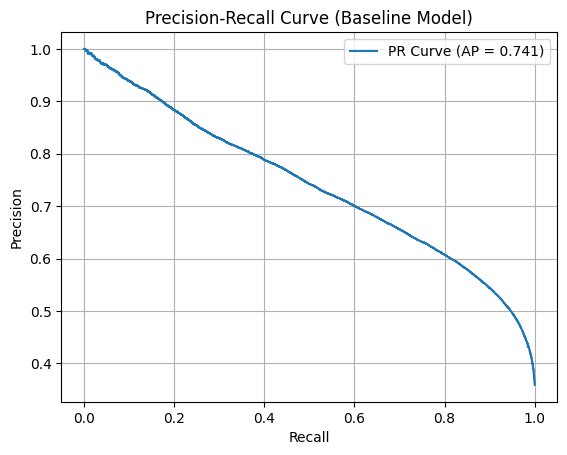

In [ ]:
# Obtener probabilidades del modelo baseline
y_scores = xgb_model.predict_proba(X_test)[:, 1]

# Calcular precision-recall
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Calcular PR-AUC
ap = average_precision_score(y_test, y_scores)

# Graficar
plt.figure()
plt.plot(recall, precision, label=f"PR Curve (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Baseline Model)")
plt.legend()
plt.grid()

plt.show()

In [ ]:
tn, fp, fn, tp = confusion_matrix(y_test, predictions_2025).ravel()

print(f"True negatives (predicted safe, was safe): {tn:,}")
print(f"False Positive (predicted incident, was safe): {fp:,} false alarms)")
print(f"False Negatives (predicted safe, was an incident) {fn:,} <- This is the danger, must be low")
print(f"True Positives (predicted incident, was an incident): {tp:,}")

True negatives (predicted safe, was safe): 91,072
False Positive (predicted incident, was safe): 14,131 false alarms)
False Negatives (predicted safe, was an incident) 24,581 <- This is the danger, must be low
True Positives (predicted incident, was an incident): 34,373


In [ ]:
def optimize_recall(modelo, X_test, y_test, new_threshold=0.40):

    # Instead of predict(), we get the exact probability, from 0 to 1
    # [:,1] takes the probability that class 1 (incident) happens
    probabilities = modelo.predict_proba(X_test)[:, 1]

    # Applying new threshold, if probability is greater than threshold is 1, otherwise 0
    adjusted_predictions = (probabilities >= new_threshold).astype(int)

    print("New Threshold report:")
    print(classification_report(y_test, adjusted_predictions))

    # Extracting the confussion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, adjusted_predictions).ravel()

    print("Adjusted Confusion matrix")
    print(f"True negatives: {tn:,}")
    print(f"False Positive (Falsas Alarmas): {fp:,} <- Subirán (Es el costo)")
    print(f"False Negatives  (EL PELIGRO): {fn:,} <- DEBEN BAJAR")
    print(f"True Positives (SALVADOS): {tp:,} <- DEBEN SUBIR")

    return adjusted_predictions

In [ ]:
predicciones_optimas = optimize_recall(xgb_model, X_test, y_test, new_threshold=0.40)

New Threshold report:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81    105203
           1       0.66      0.69      0.67     58954

    accuracy                           0.76    164157
   macro avg       0.74      0.74      0.74    164157
weighted avg       0.76      0.76      0.76    164157

Adjusted Confusion matrix
True negatives: 84,668
False Positive (Falsas Alarmas): 20,535 <- Subirán (Es el costo)
False Negatives  (EL PELIGRO): 18,560 <- DEBEN BAJAR
True Positives (SALVADOS): 40,394 <- DEBEN SUBIR


In [ ]:
def hyperparameter_tuning(X_train, y_train, classes_weights):

  # 3 splits across the time series
  time_series_split = TimeSeriesSplit(n_splits=3)

  # Model optimized
  xgb_model = xgb.XGBClassifier(
    scale_pos_weight=classes_weights,
    random_state = 42,
    n_jobs = 1, # use all cores in cpu
    tree_method='hist',
    eval_metric='logloss'
    )

  # hyperparameters space
  parameters_space = {
    'max_depth': [3, 5, 7, 9],      # Rules depth, ex: rain, huimdity and hour
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],      # % of rows used per tree
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0], # % of cols per tree
    'min_child_weight': [1, 3, 5, 7]      # blocks from learning from the noise
  }


  # Random search over the hyper-parameters space
  search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=parameters_space,
    n_iter=15,                                # number of iterations
    scoring='average_precision',              # balance between precision and recall
    cv=time_series_split,
    verbose=2,
    random_state=42,
    n_jobs=1
  )

  start = time.time()
  search.fit(X_train, y_train)
  end = time.time()

  # results
  minutos = (start - end) / 60
  print(f"Tiempo de ejecución: {minutos:.2f} minutos")
  print("LA ARQUITECTURA GANADORA ES:")
  for param, valor in search.best_params_.items():
    print(f"-> {param}: {valor}")

  print(f"\nMejor Score (PR-AUC) en validación: {search.best_score_:.4f}")

  return search.best_estimator_

In [ ]:
hyperparameterized_model = hyperparameter_tuning(X_train, y_train, classes_weights)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END colsample_bytree=0.9, learning_rate=0.01, max_depth=3, min_child_weight=7, subsample=0.8; total time=   4.7s
[CV] END colsample_bytree=0.9, learning_rate=0.01, max_depth=3, min_child_weight=7, subsample=0.8; total time=   9.5s
[CV] END colsample_bytree=0.9, learning_rate=0.01, max_depth=3, min_child_weight=7, subsample=0.8; total time=  12.9s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=7, min_child_weight=3, subsample=0.8; total time=   6.5s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=7, min_child_weight=3, subsample=0.8; total time=  12.2s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=7, min_child_weight=3, subsample=0.8; total time=  17.6s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=9, min_child_weight=7, subsample=0.7; total time=   7.6s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=9, min_child_weight=7, subsample=0.7; total time=  14.

In [ ]:
def final_model_evaluation(modelo_campeon, X_test, y_test, umbral=0.40):
    print("--- INICIANDO FASE 7: EVALUACIÓN FINAL SOBRE EL FUTURO (2025) ---")

    # Extraemos las probabilidades puras del modelo optimizado
    probabilidades = modelo_campeon.predict_proba(X_test)[:, 1]

    # Aplicamos el umbral estratégico
    predicciones_finales = (probabilidades >= umbral).astype(int)

    print(f"\nREPORTE DE RENDIMIENTO (UMBRAL: {umbral * 100}%)")
    print("="*50)
    print(classification_report(y_test, predicciones_finales))

    # La Matriz de Confusión Final
    tn, fp, fn, tp = confusion_matrix(y_test, predicciones_finales).ravel()

    print("\nMATRIZ DE CONFUSIÓN DEFINITIVA:")
    print(f"Verdaderos Negativos (Días Pacíficos): {tn:,}")
    print(f"Falsos Positivos (Falsas Alarmas): {fp:,}")
    print(f"Falsos Negativos (Desastres Omitidos): {fn:,}")
    print(f"Verdaderos Positivos (Desastres Prevenidos): {tp:,}")

    # Cálculo de métricas de negocio
    recall_final = tp / (tp + fn)
    precision_final = tp / (tp + fp)

    print("\nMÉTRICAS DE NEGOCIO (PROTECCIÓN CIVIL):")
    print(f"-> Tasa de Captura (Recall): {recall_final * 100:.1f}% de las inundaciones fueron detectadas.")
    print(f"-> Precisión de Alarma: {precision_final * 100:.1f}% de las alertas fueron reales.")


In [ ]:
final_model_evaluation(hyperparameterized_model, X_test, y_test, umbral=0.40)

--- INICIANDO FASE 7: EVALUACIÓN FINAL SOBRE EL FUTURO (2025) ---

REPORTE DE RENDIMIENTO (UMBRAL: 40.0%)
              precision    recall  f1-score   support

           0       0.83      0.80      0.81    105203
           1       0.66      0.72      0.69     58954

    accuracy                           0.77    164157
   macro avg       0.75      0.76      0.75    164157
weighted avg       0.77      0.77      0.77    164157


MATRIZ DE CONFUSIÓN DEFINITIVA:
Verdaderos Negativos (Días Pacíficos): 83,828
Falsos Positivos (Falsas Alarmas): 21,375
Falsos Negativos (Desastres Omitidos): 16,696
Verdaderos Positivos (Desastres Prevenidos): 42,258

MÉTRICAS DE NEGOCIO (PROTECCIÓN CIVIL):
-> Tasa de Captura (Recall): 71.7% de las inundaciones fueron detectadas.
-> Precisión de Alarma: 66.4% de las alertas fueron reales.


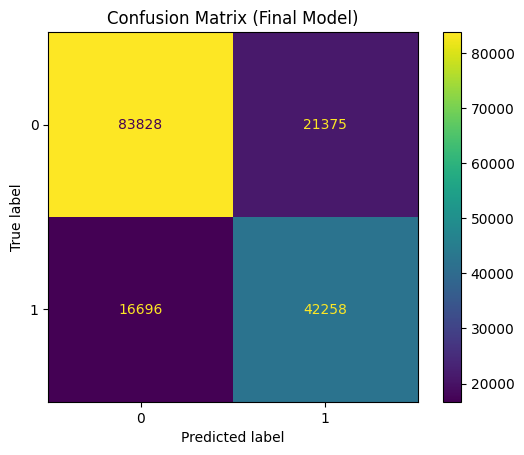

In [ ]:
y_pred_final = (hyperparameterized_model.predict_proba(X_test)[:,1] >= 0.40).astype(int)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final)

plt.title("Confusion Matrix (Final Model)")
plt.show()

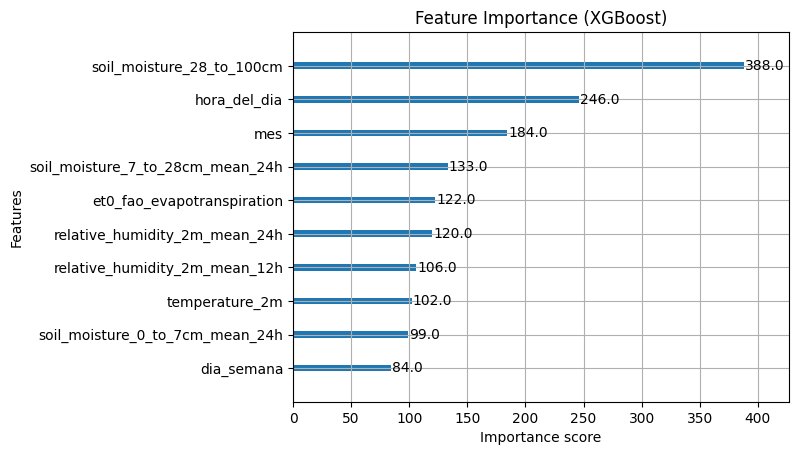

In [ ]:
xgb.plot_importance(hyperparameterized_model, max_num_features=10)

plt.title("Feature Importance (XGBoost)")
plt.show()